In [40]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [41]:
import sys

!{sys.executable} -m pip install numpy pandas matplotlib

You should consider upgrading via the 'C:\Users\quart\AppData\Local\Programs\MUEDIT~1\Python\pythonw.exe -m pip install --upgrade pip' command.


In [42]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [ ]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [44]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [45]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        legal_actions = []
        row, col = state

        for action in MOVES:
            move = MOVES[action]
            after_move = (row + move[0], col + move[1])

            if self.in_bounds(after_move):
                if self.is_free(after_move):
                    legal_actions.append(action)

        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        row, col = state
        move = MOVES[action]
        return (row + move[0], col + move[1])

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        return 1

In [46]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [47]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [48]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

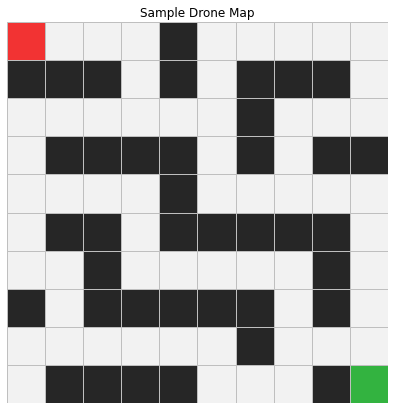

In [49]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [50]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [ ]:
from collections import deque


class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        node = Node(problem.initial_state())

        nodes_expanded = 0
        max_frontier_size = 1

        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=nodes_expanded,
                max_frontier_size=max_frontier_size,
            )

        frontier = deque([node])
        reached = {problem.initial_state()}

        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1

            for child in self.expand(problem, node):
                if problem.is_goal(child.state):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached),
                    )

                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)

            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )

In [ ]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        nodes_expanded = 0
        max_frontier_size = 0

        node = Node(problem.initial_state())

        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=nodes_expanded,
                max_frontier_size=max_frontier_size,
            )

        frontier = [node]
        reached = {problem.initial_state()}

        while frontier:
            node = frontier.pop()
            nodes_expanded += 1

            for child in self.expand(problem, node):
                if problem.is_goal(child.state):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                    )
                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)
                    max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )

In [ ]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:

        if problem.is_goal(node.state):
            return node, "success"

        elif node.depth >= limit:
            return None, "cutoff"

        else:
            cutoff_occurred = False
            metrics["nodes_expanded"] += 1

            for child in self.expand(problem, node):
                if state_is_on_path(node, child.state):
                    continue

                metrics["max_stack_size"] = max(
                    metrics["max_stack_size"], current_stack_size + 1
                )

                result, status = self._recursive_dls(
                    problem=problem,
                    node=child,
                    limit=limit,
                    metrics=metrics,
                    current_stack_size=current_stack_size + 1,
                )

                if status == "success":
                    return result, "success"

                elif status == "cutoff":
                    cutoff_occurred = True

            if cutoff_occurred:
                return None, "cutoff"
            else:
                return None, "failure"


In [ ]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        dls = DepthLimitedSearch()
        iteration_log = []

        total_nodes = 0
        max_stack = 0

        for limit in range(max_depth + 1):
            result = dls.search(problem, limit=limit)
            status = result.status
            iteration_log.append((limit, status))

            total_nodes += result.nodes_expanded
            max_stack = max(max_stack, result.max_frontier_size)

            if status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status=status,
                    solution=result.solution,
                    nodes_expanded=total_nodes,
                    max_frontier_size=max_stack,
                    reached_count=0,
                    limit=limit,
                    iterations=iteration_log,
                )
            elif status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status=status,
                    solution=None,
                    nodes_expanded=total_nodes,
                    max_frontier_size=max_stack,
                    reached_count=0,
                    limit=limit,
                    iterations=iteration_log,
                )

        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes,
            max_frontier_size=max_stack,
            reached_count=0,
            limit=max_depth,
            iterations=iteration_log,
        )


In [65]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=2),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,52
1,DFS,success,NaN,18.0,18.0,18,4,0
2,DLS,cutoff,2.0,NaN,NaN,2,3,0
3,IDS,success,18.0,18.0,18.0,356,19,0


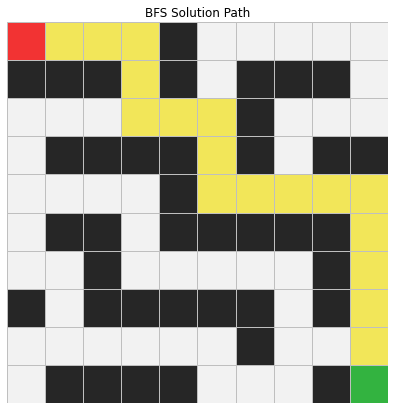

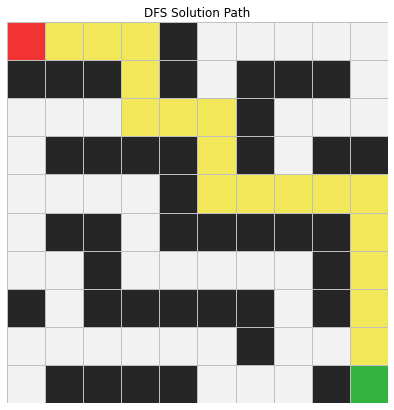

In [66]:
bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

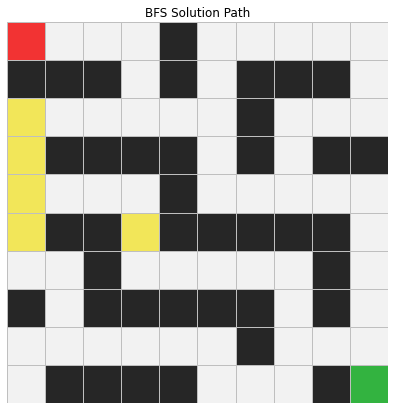

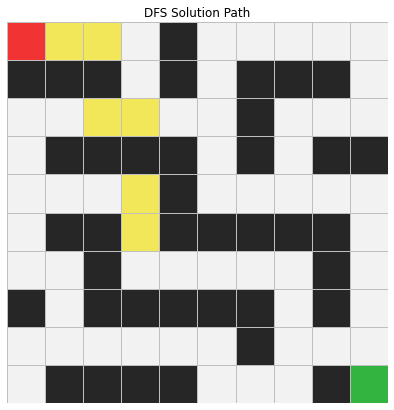

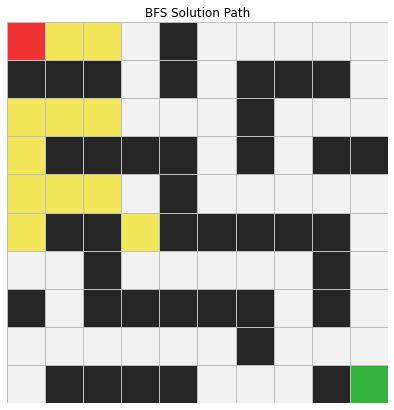

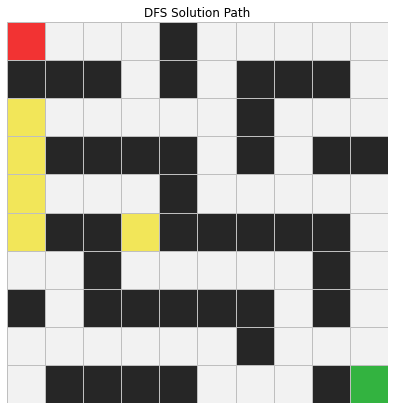

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,9,9,28,5,28
1,DFS,success,NaN,9,9,24,10,0
2,DLS,success,20.0,19,19,22,21,0
3,IDS,success,9.0,9,9,736,10,0


In [ ]:
custom_grid_1 = [
    [0, 0, 0, 0, 1],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0],
    [1, 0, 0, 1, 0],
]

custom_start_1 = (0, 0)
custom_goal_1 = (5, 4)

custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]

bfs_result = custom_results_1[0]
dfs_result = custom_results_1[1]
dls_result = custom_results_1[2]
ids_result = custom_results_1[3]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)
plot_path(
    sample_grid,
    start,
    goal,
    path=dls_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=ids_result.path,
    title="DFS Solution Path",
)

show_results(custom_results_1)

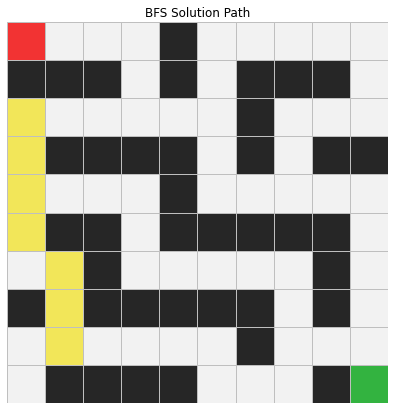

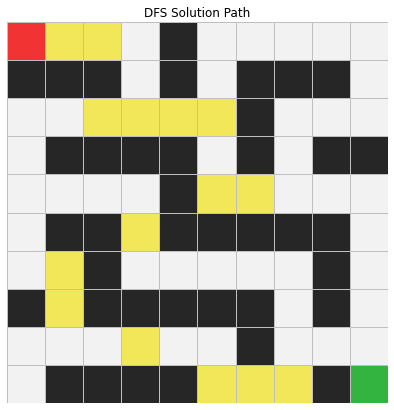

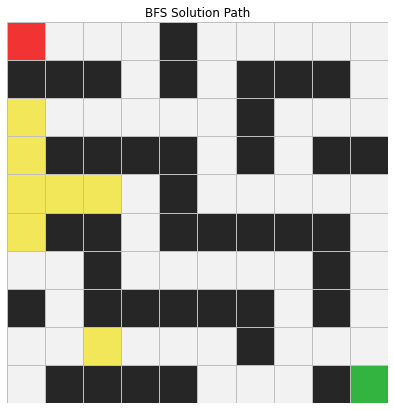

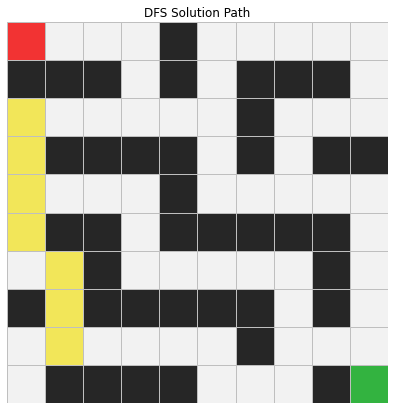

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18,18,82,12,83
1,DFS,success,NaN,28,28,44,26,0
2,DLS,success,20.0,20,20,2694,21,0
3,IDS,success,18.0,18,18,359814,19,0


In [ ]:
custom_grid_1 = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 0, 0, 1, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
]

custom_start_1 = (0, 0)
custom_goal_1 = (10, 8)

custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]

bfs_result = custom_results_1[0]
dfs_result = custom_results_1[1]
dls_result = custom_results_1[2]
ids_result = custom_results_1[3]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)
plot_path(
    sample_grid,
    start,
    goal,
    path=dls_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=ids_result.path,
    title="DFS Solution Path",
)

show_results(custom_results_1)

Reflection Questions

15.1 Problem Formulation

What is a state in this lab?
A state is a space the node is in currently

What is an action?
An action is the result state the node is in after movement

What does the result function do?
The result function produces the next state the node would be in after taking an action on its current state

Why is it useful to separate the problem definition from the search algorithm?
This makes it easier for the search algorithm to be reusable with other problems by separating what the problem actually is and how it is solved


15.2 BFS
Why does BFS use a FIFO queue?
This is because it allows for each nodes to be explored in the order they were discovered in level by level, thus ensuring the shallowest nodes are expanded first

Why does BFS find the shortest path in terms of number of steps on the unweighted grid?
This is beacuse BFS ensures that the nodes at the shallowest depths are explored before going deeper, and since on an unweighted grid each move has the same cost, getting to the goal cell with the fewest steps is guaranteed with the first path


What role does the reached set play in BFS?
The reached set shows the nodes that have already been explored in the algorithm so that it does not go back and explore nodes that have already been explored

15.3 DFS
Why does DFS use a stack?
It uses a stack because the algorithm continues with the most recent node which allows it to go as deep as possible before going down another path

Is DFS guaranteed to find the shortest path? Explain.
No because it explores ine branch deeply initially and may reach a goal down the longer path before going to the short ones

Under what conditions can DFS use less memory than BFS?
DFS uses less memory when the search tree is deep

Under what conditions can DFS perform badly?
It perform badly when the search tree is very deep or contains long irrelevant paths

15.4 DLS
What happens when the depth limit is too small?
The algorithm might stop searching before it reaches a goal even if the solution may be deeper in the tree

What is the meaning of "cutoff"?
The point where the algorithm hits the depth limit and stops searching

How is DLS different from ordinary DFS?
DLS is a DFS but with a fixed depth limit so it does not go further when the limiti has been reached however DFS had no limit

Why do we use path-cycle checking in DLS?
This prevents the algorithm from going in circles so states that have already been explored are not revisited

15.5 IDS
Why does IDS repeat DLS with increasing limits?
To ensure that the goal is eventually found and ensuring that the shallowest solutions are found before deeper solutions are also found

Why can IDS be complete even though DLS with a small limit is not?
This is because IDS will eventually increase its depth limit to find a solution but DLS will stop at a fixed limit regardless of whther a solution has been found

Why does IDS use less memory than BFS?
IDS only stores the nodes on the current path instaed of storing all nodes like BFS

What is the cost of repeatedly searching from the root?
IDS will keep expanding those same nodes at different depth limits thus increasing the total time taken to find a solution

15.6 Real-World Drone Context
In a real drone application, what might make one route safer or more practical than another?
Factors like weather and wind conditions, objects such as trees, buildings etc, could make a route more safer than another

Which algorithm would you choose if all moves are equally costly and you only care about the fewest number of moves? Explain.
I would use Breadth First Search because it explores the search space level by level thus it guarantees that when a goal is found, the least number od moves were used

Which algorithm would you choose if you want to limit how deep the drone is allowed to search? Explain.
I would use Depth Limit Search because a depth limit can be set so that when the algorithm reaches that limit, it stops searching for a solution. This allows for more control on how far the search goes

What limitations does this grid model have compared with real drone navigation?
The grid is a more simplified abstracted version and does not factor in many real world situations like the drone would. Motion with the drone is not fixed and can be continuous and smooth whilst ignoring obstacles like buildings and power lines but with the grid obstacles are only represented  by blocked cells which over simplify it. This means that paths that may be optimal on the grid may not be safe or feasible in real life with the drone because so many factors decide how far the drone could go.
